In [15]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [16]:
with open('data/expand_sparsify_176_results.pkl', 'rb') as f:
    gs_single = pickle.load(f)

with open('data/expand_sparsify_176_mix_results.pkl', 'rb') as f:
    gs_mix = pickle.load(f)

## Expand-and-sparsify 176 — Gridsearch results

Expansion: 8 raw + derivatives to 7th order (56) + 56 ratios + 56 differences = **176 traces**.

Parameters swept:
- **p_hd** – HD Bernoulli sampling probability
- **d** – sparsity (fraction of HD neurons zeroed out)

Fixed: `n_hd = 10,000`, 10 repeats per combo.

Datasets:
- **Single gas**: `1_600_20` (n_train=450, sequence split)
- **Binary mix**: `mix_100_20_1` (train) / `mix_50_20_1` (test)

In [17]:
def build_grid(data):
    """Build 2-D grid (p_hd x d) of mean accuracy from acc_table dict."""
    p_hd_vals = np.array(data['p_hd_sweep'])
    d_vals    = np.array(data['d_sweep'])
    config    = data['config_names'][0]

    grid_mean = np.full((len(p_hd_vals), len(d_vals)), np.nan)
    grid_std  = np.full((len(p_hd_vals), len(d_vals)), np.nan)

    for i, p in enumerate(p_hd_vals):
        for j, d in enumerate(d_vals):
            key = (config, p, d)
            if key in data['acc_table']:
                m, s = data['acc_table'][key]
                grid_mean[i, j] = float(m)
                grid_std[i, j]  = float(s)

    return grid_mean, grid_std, p_hd_vals, d_vals

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_58230/2402571068.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


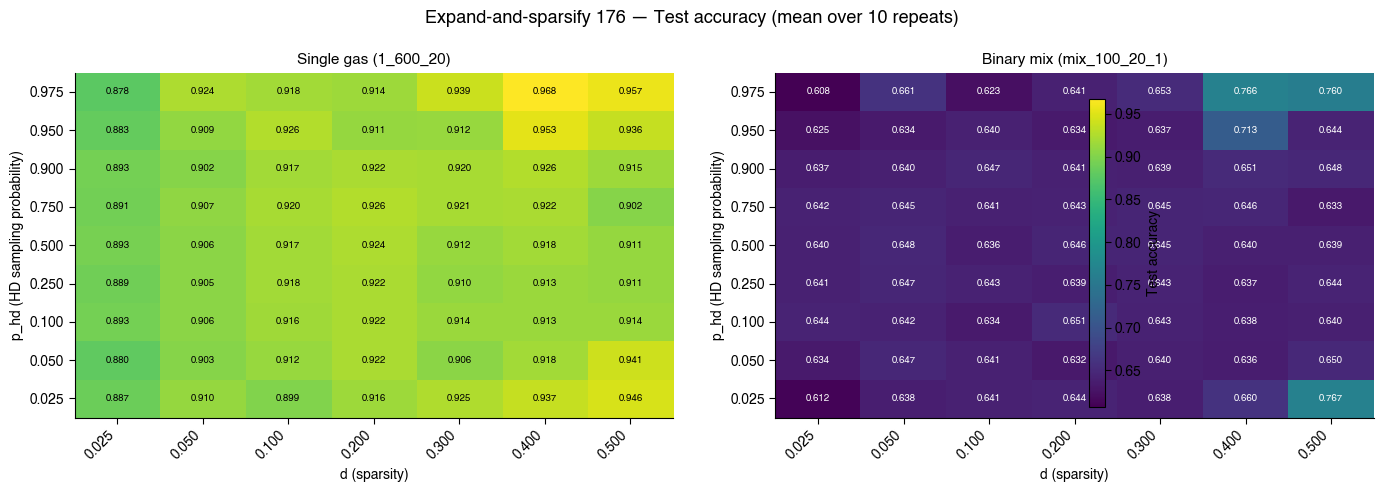

In [18]:
datasets = {
    'Single gas (1_600_20)': gs_single,
    'Binary mix (mix_100_20_1)': gs_mix,
}

# global colour scale across both datasets
all_means = [build_grid(d)[0] for d in datasets.values()]
vmin = np.nanmin([g.min() for g in all_means])
vmax = np.nanmax([g.max() for g in all_means])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Expand-and-sparsify 176 — Test accuracy (mean over 10 repeats)',
             fontsize=13, fontweight='bold')

for col, (title, data) in enumerate(datasets.items()):
    ax = axes[col]
    grid_mean, grid_std, p_hd_vals, d_vals = build_grid(data)

    im = ax.imshow(grid_mean, aspect='auto', origin='lower',
                   cmap='viridis', vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(d_vals)))
    ax.set_xticklabels([f'{v:.3f}' for v in d_vals], rotation=45, ha='right')
    ax.set_yticks(np.arange(len(p_hd_vals)))
    ax.set_yticklabels([f'{v:.3f}' for v in p_hd_vals])
    ax.set_xlabel('d (sparsity)', fontsize=10)
    ax.set_ylabel('p_hd (HD sampling probability)', fontsize=10)
    ax.set_title(title, fontsize=11)

    thresh = (vmin + vmax) / 2
    for i in range(grid_mean.shape[0]):
        for j in range(grid_mean.shape[1]):
            if np.isfinite(grid_mean[i, j]):
                color = 'white' if grid_mean[i, j] < thresh else 'black'
                ax.text(j, i, f'{grid_mean[i, j]:.3f}',
                        ha='center', va='center', fontsize=7, color=color)

fig.colorbar(im, ax=axes, label='Test accuracy', shrink=0.8)
plt.tight_layout()
plt.show()

In [19]:
# Best params summary
for label, data in datasets.items():
    grid_mean, grid_std, p_hd_vals, d_vals = build_grid(data)
    best_idx = np.unravel_index(np.nanargmax(grid_mean), grid_mean.shape)
    best_p = p_hd_vals[best_idx[0]]
    best_d = d_vals[best_idx[1]]
    best_m = grid_mean[best_idx]
    best_s = grid_std[best_idx]
    print(f'[{label}] Best: p_hd={best_p:.3f}, d={best_d:.3f}  '
          f'mean={best_m:.4f} ± {best_s:.4f}')

[Single gas (1_600_20)] Best: p_hd=0.975, d=0.400  mean=0.9678 ± 0.0023
[Binary mix (mix_100_20_1)] Best: p_hd=0.025, d=0.500  mean=0.7665 ± 0.0041


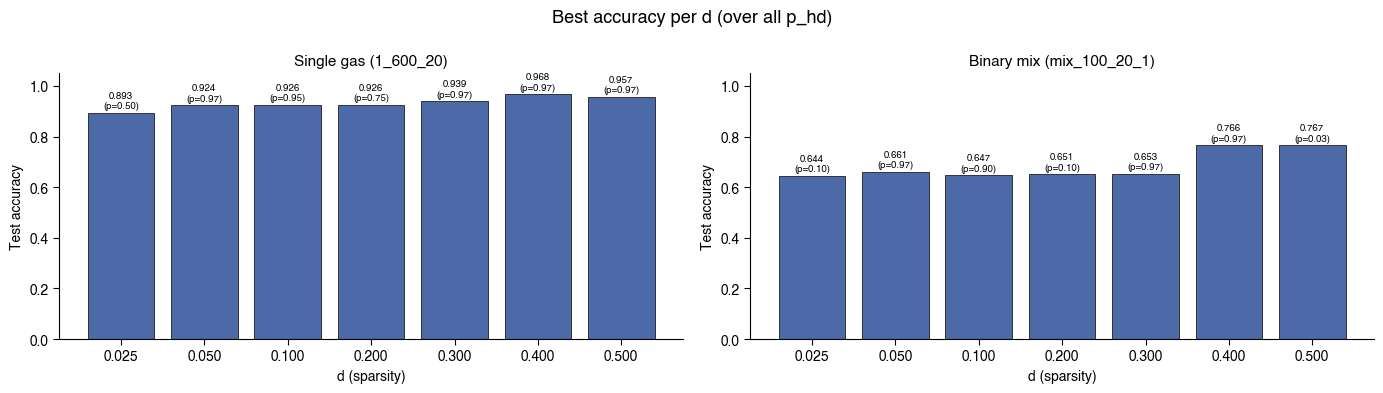

In [20]:
# Bar plot: best accuracy per d value (marginalising over p_hd)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Best accuracy per d (over all p_hd)', fontsize=13, fontweight='bold')

for col, (label, data) in enumerate(datasets.items()):
    ax = axes[col]
    grid_mean, grid_std, p_hd_vals, d_vals = build_grid(data)

    best_per_d = np.nanmax(grid_mean, axis=0)
    best_p_idx = np.nanargmax(grid_mean, axis=0)

    bars = ax.bar(np.arange(len(d_vals)), best_per_d, color='C0',
                  edgecolor='k', linewidth=0.5)
    ax.set_xticks(np.arange(len(d_vals)))
    ax.set_xticklabels([f'{v:.3f}' for v in d_vals])
    ax.set_xlabel('d (sparsity)')
    ax.set_ylabel('Test accuracy')
    ax.set_title(label, fontsize=11)
    ax.set_ylim(0, 1.05)

    for i, (m, pidx) in enumerate(zip(best_per_d, best_p_idx)):
        ax.text(i, m + 0.01, f'{m:.3f}\n(p={p_hd_vals[pidx]:.2f})',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

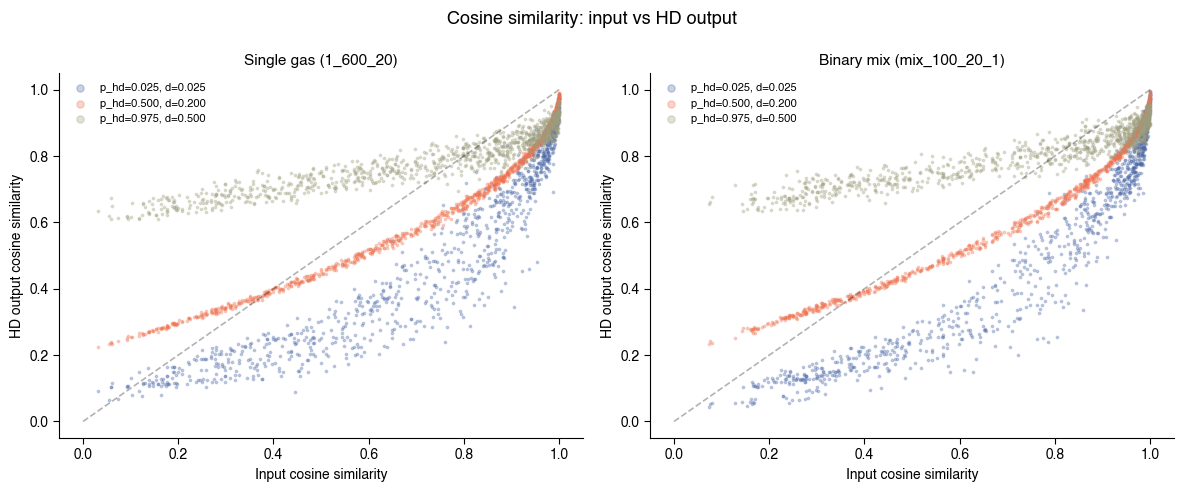

In [21]:
# Cosine similarity scatter: input vs output per (p_hd, d)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Cosine similarity: input vs HD output', fontsize=13, fontweight='bold')

for col, (label, data) in enumerate(datasets.items()):
    ax = axes[col]
    config = data['config_names'][0]
    cos_in = data['cos_input'][config]

    # plot a few representative (p_hd, d) combos
    p_hd_vals = data['p_hd_sweep']
    d_vals = data['d_sweep']
    combos = [
        (p_hd_vals[0], d_vals[0]),   # low p_hd, low d
        (p_hd_vals[4], d_vals[3]),   # mid p_hd, mid d
        (p_hd_vals[-1], d_vals[-1]), # high p_hd, high d
    ]

    for p, d in combos:
        key = (config, p, d)
        if key in data['cos_output']:
            cos_out = data['cos_output'][key]
            ax.scatter(cos_in, cos_out, s=3, alpha=0.3,
                       label=f'p_hd={p:.3f}, d={d:.3f}')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Input cosine similarity')
    ax.set_ylabel('HD output cosine similarity')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()